[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/healthcareaibook/blob/main/vol%201%20notebooks/chapter_06/notebook_6_5_lung_nodule_detection.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# Notebook 6.5: Lung Nodule Detection with Object Detection

**Chapter 6: Medical Imaging - Implementing Journey 3 (Jamal)**

**Journey Connection**: This notebook implements Journey 3 from Chapter 3, where Jamal received false positive alerts from a lung nodule screening system. For the clinical context and patient story, refer to Chapter 3.

## Learning Objectives

By the end of this notebook, you will be able to:
1. Generate synthetic 2D CT slices with nodule candidates
2. Implement a simple nodule detector using intensity thresholding and morphology
3. Calculate Intersection over Union (IoU) for bounding box evaluation
4. Generate Free-Response ROC (FROC) curves for detection tasks
5. Understand why high false positive rates are inherent to screening

## Clinical Context

Lung cancer screening with low-dose CT saves lives by detecting early-stage disease. However, the vast majority of detected nodules are benign.

**Jamal's story**: 62-year-old former smoker. Screening CT identified a 6mm nodule. AI system flagged it as suspicious. After 6 months of follow-up CTs and a biopsy, the nodule was confirmed benign. The anxiety and cost were significant.

**The challenge**:
- Only ~4% of detected nodules are malignant
- Systems must be highly sensitive (can't miss cancer)
- This inevitably leads to many false positives
- FROC curves show performance across different sensitivity/FP trade-offs

---

## Setup

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy import ndimage
from scipy.ndimage import label, binary_erosion, binary_dilation
from sklearn.metrics import roc_curve, auc
from skimage import morphology, measure
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Generate Synthetic CT Data

We'll create simplified 2D CT slices with:
- Lung parenchyma background
- True nodules (some malignant, some benign)
- False positive candidates (blood vessels, artifacts)

In reality, you would use datasets like LUNA16 or LIDC-IDRI.

In [3]:
def generate_synthetic_ct_slice(size=256, n_nodules=0, n_fp_candidates=0):
    """
    Generate a synthetic 2D CT slice.

    Parameters:
    - size: Image dimensions (size x size)
    - n_nodules: Number of true nodules
    - n_fp_candidates: Number of false positive candidates (vessels, etc.)

    Returns:
    - ct_slice: The CT image
    - nodule_boxes: List of (x, y, w, h, malignant) for true nodules
    - fp_boxes: List of (x, y, w, h) for false positive candidates
    """

    # Create lung background (approximately -850 HU in reality, we use 0.2 normalized)
    ct_slice = np.random.normal(0.2, 0.05, (size, size))

    # Add texture (simulate lung parenchyma)
    texture = np.random.normal(0, 0.02, (size, size))
    ct_slice += texture

    nodule_boxes = []
    fp_boxes = []

    # Add true nodules
    for i in range(n_nodules):
        # Nodule size: 4-20mm
        nodule_size = np.random.randint(4, 20)
        r = nodule_size // 2  # Radius

        # Random location (avoid extreme edges)
        x = np.random.randint(30, size - 30)
        y = np.random.randint(30, size - 30)

        # Malignant probability
        malignant = nodule_size > 10 and np.random.rand() < 0.3

        # 1. GENERATE MASK (Covers full potential area)
        # We use a slightly larger grid to be safe, then slice it later
        y_grid, x_grid = np.ogrid[-r:r, -r:r]
        mask = x_grid**2 + y_grid**2 <= r**2

        nodule_intensity = np.random.uniform(0.5, 0.7)

        # 2. CALCULATE VALID IMAGE BOUNDS (Clipping)
        y_start = max(0, y - r)
        y_end = min(size, y + r)
        x_start = max(0, x - r)
        x_end = min(size, x + r)

        # 3. CALCULATE VALID MASK BOUNDS (Relative to the mask)
        # Calculate how tall/wide the destination area actually is
        h_dest = y_end - y_start
        w_dest = x_end - x_start

        # If the nodule is completely off-screen (shouldn't happen with current x,y limits), skip
        if h_dest <= 0 or w_dest <= 0:
            continue

        # Calculate where to slice the mask to match the destination
        # (Start index in mask is the difference between ideal start and clipped start)
        mask_y_start = y_start - (y - r)
        mask_y_end = mask_y_start + h_dest
        mask_x_start = x_start - (x - r)
        mask_x_end = mask_x_start + w_dest

        # 4. APPLY (Now shapes are guaranteed to match)
        ct_slice[y_start:y_end, x_start:x_end] = np.where(
            mask[mask_y_start:mask_y_end, mask_x_start:mask_x_end],
            nodule_intensity,
            ct_slice[y_start:y_end, x_start:x_end]
        )

        # Store bounding box
        nodule_boxes.append((x - r, y - r, 2*r, 2*r, malignant))

    # Add false positive candidates (blood vessels, scars, etc.)
    for i in range(n_fp_candidates):
        fp_size = np.random.randint(3, 12)
        x = np.random.randint(20, size - 20)
        y = np.random.randint(20, size - 20)

        # Elongated or irregular shape (unlike spherical nodules)
        if np.random.rand() < 0.5:
            # Blood vessel (elongated)
            length = np.random.randint(10, 30)
            angle = np.random.uniform(0, np.pi)
            for t in range(length):
                px = int(x + t * np.cos(angle))
                py = int(y + t * np.sin(angle))
                if 0 <= px < size and 0 <= py < size:
                    ct_slice[py-1:py+2, px-1:px+2] = np.random.uniform(0.4, 0.6)
        else:
            # Irregular density
            ct_slice[y:y+fp_size, x:x+fp_size] = np.random.uniform(0.4, 0.6)

        fp_boxes.append((x, y, fp_size, fp_size))

    # Clip values to [0, 1]
    ct_slice = np.clip(ct_slice, 0, 1)

    return ct_slice, nodule_boxes, fp_boxes

# Generate example CT slices
print("Generating synthetic CT data...")

# Example 1: Slice with nodules
ct_with_nodules, nodules, fp_candidates = generate_synthetic_ct_slice(
    size=256, n_nodules=3, n_fp_candidates=5
)

# Example 2: Slice without nodules
ct_no_nodules, _, fp_only = generate_synthetic_ct_slice(
    size=256, n_nodules=0, n_fp_candidates=8
)

print(f"Generated CT slice with {len(nodules)} nodules and {len(fp_candidates)} FP candidates")
print(f"Malignant nodules: {sum([1 for n in nodules if n[4]])}")

Generating synthetic CT data...
Generated CT slice with 3 nodules and 5 FP candidates
Malignant nodules: 1


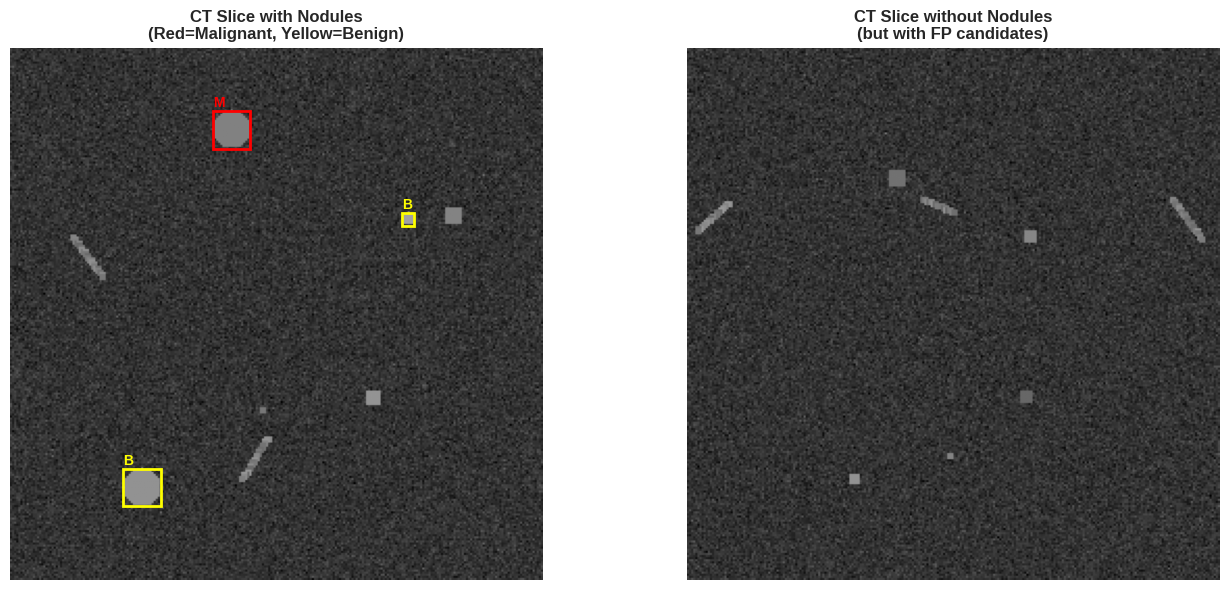


📊 Observation:
   - True nodules are spherical, solid densities
   - FP candidates (vessels, artifacts) can look similar
   - This is why automated detection has high FP rates!


In [4]:
# Visualize example CT slices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Slice with nodules
ax = axes[0]
ax.imshow(ct_with_nodules, cmap='gray', vmin=0, vmax=1)

# Draw bounding boxes for true nodules
for x, y, w, h, malignant in nodules:
    color = 'red' if malignant else 'yellow'
    rect = patches.Rectangle((x, y), w, h, linewidth=2,
                            edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    label = 'M' if malignant else 'B'
    ax.text(x, y-2, label, color=color, fontsize=10, fontweight='bold')

ax.set_title('CT Slice with Nodules\n(Red=Malignant, Yellow=Benign)',
            fontsize=12, fontweight='bold')
ax.axis('off')

# Slice without nodules
ax = axes[1]
ax.imshow(ct_no_nodules, cmap='gray', vmin=0, vmax=1)
ax.set_title('CT Slice without Nodules\n(but with FP candidates)',
            fontsize=12, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Observation:")
print("   - True nodules are spherical, solid densities")
print("   - FP candidates (vessels, artifacts) can look similar")
print("   - This is why automated detection has high FP rates!")

## 2. Simple Nodule Detector

We'll implement a basic detector using:
1. Intensity thresholding (nodules are brighter than lung tissue)
2. Size filtering (nodules are typically 4-30mm)
3. Shape analysis (nodules are roughly spherical)

This is simplified - real systems use deep learning (e.g., Faster R-CNN, RetinaNet).

In [6]:
import numpy as np
from scipy.ndimage import label, binary_erosion, binary_dilation

def detect_nodule_candidates(ct_slice, intensity_threshold=0.4,
                             min_size=10, max_size=400):
    """
    Simple nodule detector using intensity thresholding and morphology.
    """

    # Step 1: Threshold to find bright regions
    binary = ct_slice > intensity_threshold

    # Step 2: Morphological operations to clean up
    # Note: Using iterations to remove small noise and bridge gaps
    binary = binary_erosion(binary, iterations=1)
    binary = binary_dilation(binary, iterations=2)

    # Step 3: Label connected components
    # We rename the output variable 'labeled_array' to avoid confusion
    # with any 'label' variable you might have defined elsewhere.
    labeled_array, n_components = label(binary)

    detections = []

    # Step 4: Analyze each component
    for region_id in range(1, n_components + 1):
        region_mask = labeled_array == region_id
        region_size = np.sum(region_mask)

        # Size filter
        if region_size < min_size or region_size > max_size:
            continue

        # Get bounding box
        coords = np.argwhere(region_mask)
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        w = x_max - x_min + 1
        h = y_max - y_min + 1

        # Shape analysis
        aspect_ratio = max(w, h) / (min(w, h) + 1e-6)

        # Circularity
        perimeter = np.sum(region_mask != binary_erosion(region_mask, iterations=1))
        circularity = (4 * np.pi * region_size) / (perimeter**2 + 1e-6)

        # Mean intensity
        mean_intensity = np.mean(ct_slice[region_mask])

        # Confidence score
        confidence = (
            mean_intensity * min(circularity, 1.0) * (1.0 / aspect_ratio)
        )

        detections.append((x_min, y_min, w, h, confidence))

    # Sort by confidence
    detections = sorted(detections, key=lambda x: x[4], reverse=True)

    return detections

# --- Test the detector ---
# Ensure 'ct_with_nodules' exists from your previous step
detections = detect_nodule_candidates(ct_with_nodules,
                                     intensity_threshold=0.4,
                                     min_size=10,
                                     max_size=400)

print(f"Detector found {len(detections)} candidates")
if 'nodules' in globals():
    print(f"Ground truth: {len(nodules)} true nodules")

print(f"\nTop 5 detections (by confidence):")
for i, (x, y, w, h, conf) in enumerate(detections[:5]):
    print(f"  {i+1}. Box: ({x}, {y}, {w}x{h}), Confidence: {conf:.3f}")

Detector found 8 candidates
Ground truth: 3 true nodules

Top 5 detections (by confidence):
  1. Box: (53, 201, 20x20), Confidence: 0.510
  2. Box: (187, 78, 8x8), Confidence: 0.501
  3. Box: (170, 164, 9x9), Confidence: 0.468
  4. Box: (96, 29, 20x20), Confidence: 0.454
  5. Box: (208, 76, 10x10), Confidence: 0.428


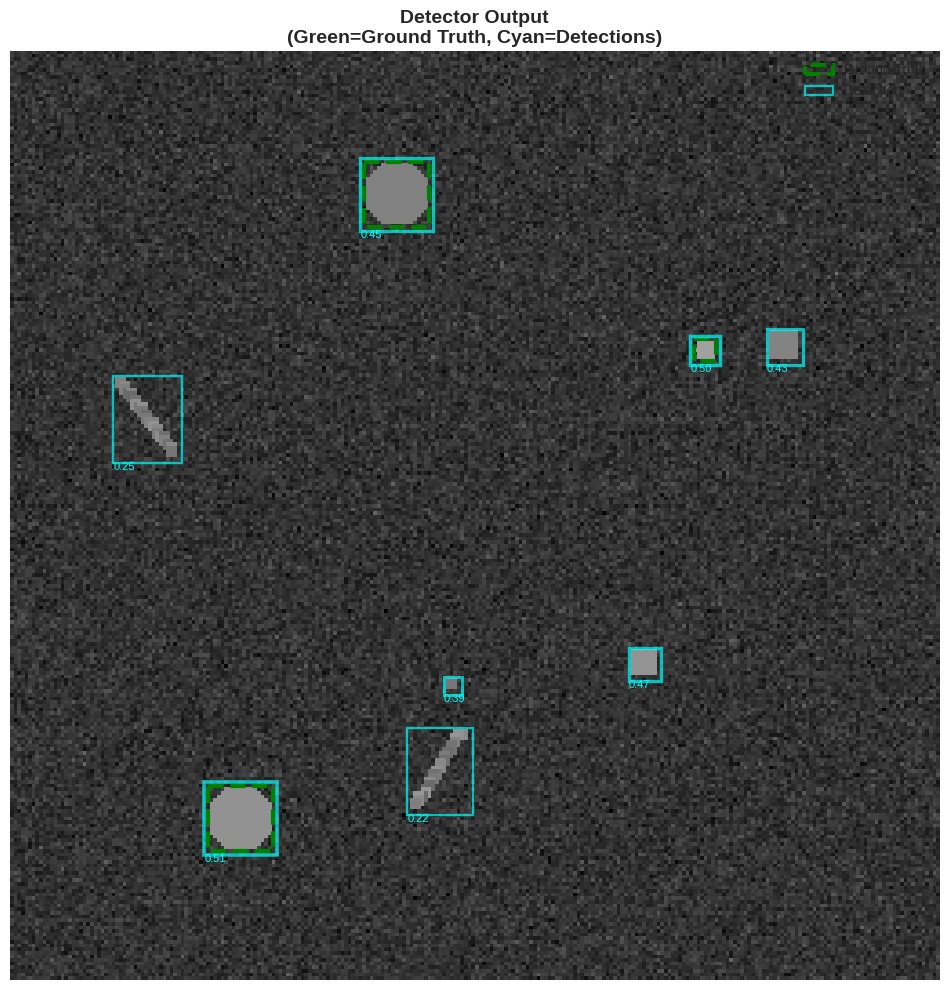


🔍 Observation:
   - Detector finds true nodules (where green and cyan overlap)
   - But also detects false positives (cyan boxes with no green)
   - Confidence scores help rank candidates


In [7]:
# Visualize detections
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(ct_with_nodules, cmap='gray', vmin=0, vmax=1)

# Draw ground truth (green)
for x, y, w, h, malignant in nodules:
    rect = patches.Rectangle((x, y), w, h, linewidth=3,
                            edgecolor='green', facecolor='none',
                            linestyle='--', label='Ground Truth')
    ax.add_patch(rect)

# Draw detections (blue, thickness by confidence)
for x, y, w, h, conf in detections[:10]:  # Top 10 detections
    rect = patches.Rectangle((x, y), w, h, linewidth=1+conf*3,
                            edgecolor='cyan', facecolor='none',
                            alpha=0.7, label='Detection')
    ax.add_patch(rect)
    ax.text(x, y+h+2, f'{conf:.2f}', color='cyan', fontsize=8)

# Remove duplicate labels
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

ax.set_title('Detector Output\n(Green=Ground Truth, Cyan=Detections)',
            fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("\n🔍 Observation:")
print("   - Detector finds true nodules (where green and cyan overlap)")
print("   - But also detects false positives (cyan boxes with no green)")
print("   - Confidence scores help rank candidates")

## 3. Intersection over Union (IoU)

To evaluate detection quality, we calculate IoU between predicted and ground truth boxes.

**IoU = Area of Overlap / Area of Union**

Typically:
- IoU > 0.5: Detection considered correct
- IoU < 0.5: False positive

In [8]:
def calculate_iou(box1, box2):
    """
    Calculate Intersection over Union for two bounding boxes.

    Boxes are (x, y, w, h)
    """
    x1, y1, w1, h1 = box1[:4]
    x2, y2, w2, h2 = box2[:4]

    # Calculate coordinates of intersection rectangle
    x_left = max(x1, x2)
    y_top = max(y1, y2)
    x_right = min(x1 + w1, x2 + w2)
    y_bottom = min(y1 + h1, y2 + h2)

    # Check if there's an intersection
    if x_right < x_left or y_bottom < y_top:
        return 0.0

    # Calculate areas
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - intersection_area

    iou = intersection_area / (union_area + 1e-6)
    return iou

def match_detections_to_ground_truth(detections, ground_truth, iou_threshold=0.5):
    """
    Match detections to ground truth nodules using IoU.

    Returns:
    - tp: List of (detection, ground_truth, iou) for true positives
    - fp: List of detections that are false positives
    - fn: List of ground truth nodules that were missed
    """
    tp = []
    fp = []
    matched_gt = set()

    for det in detections:
        best_iou = 0
        best_gt_idx = -1

        # Find best matching ground truth
        for gt_idx, gt in enumerate(ground_truth):
            if gt_idx in matched_gt:
                continue

            iou = calculate_iou(det, gt)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        # Check if match is good enough
        if best_iou >= iou_threshold:
            tp.append((det, ground_truth[best_gt_idx], best_iou))
            matched_gt.add(best_gt_idx)
        else:
            fp.append(det)

    # Find false negatives (missed ground truth)
    fn = [gt for i, gt in enumerate(ground_truth) if i not in matched_gt]

    return tp, fp, fn

# Match detections to ground truth
tp, fp, fn = match_detections_to_ground_truth(detections, nodules, iou_threshold=0.5)

print(f"Detection Performance (IoU threshold = 0.5):")
print(f"  True Positives:  {len(tp)}")
print(f"  False Positives: {len(fp)}")
print(f"  False Negatives: {len(fn)}")
print(f"\n  Sensitivity: {len(tp) / (len(tp) + len(fn)) * 100:.1f}%")
print(f"  Precision:   {len(tp) / (len(tp) + len(fp)) * 100:.1f}% if len(tp) + len(fp) > 0 else 0")

if len(tp) > 0:
    print(f"\nTrue Positive matches:")
    for det, gt, iou in tp[:3]:
        print(f"  Detection at ({det[0]}, {det[1]}) → GT at ({gt[0]}, {gt[1]}), IoU={iou:.3f}")

Detection Performance (IoU threshold = 0.5):
  True Positives:  3
  False Positives: 5
  False Negatives: 0

  Sensitivity: 100.0%
  Precision:   37.5% if len(tp) + len(fp) > 0 else 0

True Positive matches:
  Detection at (53, 201) → GT at (54, 202), IoU=0.810
  Detection at (187, 78) → GT at (188, 79), IoU=0.562
  Detection at (96, 29) → GT at (97, 30), IoU=0.810


## 4. Generate Dataset and FROC Curve

**Free-Response ROC (FROC)** curve shows:
- X-axis: False positives per image
- Y-axis: Sensitivity (fraction of nodules detected)

This is more appropriate for detection than standard ROC.

In [9]:
# Generate a larger dataset
print("Generating dataset of CT slices...")

n_slices = 100
dataset = []

for i in range(n_slices):
    # Vary number of nodules (some slices have 0-3 nodules)
    n_nodules = np.random.choice([0, 0, 0, 1, 1, 2, 3], p=[0.3, 0.2, 0.1, 0.2, 0.1, 0.05, 0.05])
    n_fp = np.random.randint(3, 10)

    ct_slice, nodules, fp_cands = generate_synthetic_ct_slice(
        size=256, n_nodules=n_nodules, n_fp_candidates=n_fp
    )

    # Run detector
    detections = detect_nodule_candidates(ct_slice, intensity_threshold=0.4)

    dataset.append({
        'slice_id': i,
        'ct_slice': ct_slice,
        'ground_truth': nodules,
        'detections': detections,
        'n_nodules': len(nodules)
    })

total_nodules = sum([d['n_nodules'] for d in dataset])
total_detections = sum([len(d['detections']) for d in dataset])

print(f"\nDataset statistics:")
print(f"  Total slices: {n_slices}")
print(f"  Total nodules: {total_nodules}")
print(f"  Slices with nodules: {sum([1 for d in dataset if d['n_nodules'] > 0])}")
print(f"  Total detections: {total_detections}")
print(f"  Avg detections per slice: {total_detections / n_slices:.1f}")

Generating dataset of CT slices...

Dataset statistics:
  Total slices: 100
  Total nodules: 55
  Slices with nodules: 40
  Total detections: 631
  Avg detections per slice: 6.3


Calculating FROC curve...


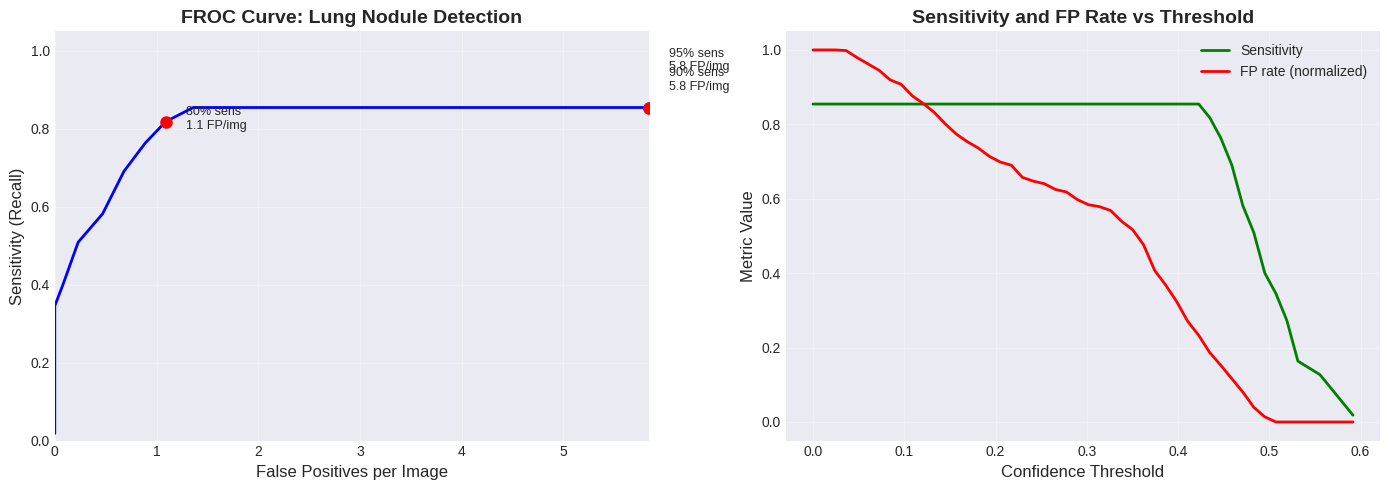


⚠️  FROC Analysis:
   To achieve 95% sensitivity (catch 95% of nodules):
   → Need to accept 5.8 false positives per image
   → Over 100 slices, that's ~584 false alarms!

   This is why Jamal (and many patients) experience false positives.


In [10]:
# Calculate FROC curve
def calculate_froc(dataset, iou_threshold=0.5, confidence_thresholds=None):
    """
    Calculate FROC curve: sensitivity vs FP per image.
    """
    if confidence_thresholds is None:
        # Get all confidence values
        all_confidences = []
        for data in dataset:
            all_confidences.extend([d[4] for d in data['detections']])
        confidence_thresholds = np.linspace(0, max(all_confidences), 50)

    sensitivities = []
    fp_per_image = []

    for threshold in confidence_thresholds:
        total_tp = 0
        total_fp = 0
        total_fn = 0

        for data in dataset:
            # Filter detections by confidence
            filtered_dets = [d for d in data['detections'] if d[4] >= threshold]

            # Match to ground truth
            tp, fp, fn = match_detections_to_ground_truth(
                filtered_dets, data['ground_truth'], iou_threshold
            )

            total_tp += len(tp)
            total_fp += len(fp)
            total_fn += len(fn)

        # Calculate metrics
        sensitivity = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
        fp_rate = total_fp / len(dataset)  # FP per image

        sensitivities.append(sensitivity)
        fp_per_image.append(fp_rate)

    return np.array(fp_per_image), np.array(sensitivities), confidence_thresholds

# Calculate FROC
print("Calculating FROC curve...")
fp_rates, sensitivities, thresholds = calculate_froc(dataset, iou_threshold=0.5)

# Plot FROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FROC curve
ax = axes[0]
ax.plot(fp_rates, sensitivities, 'b-', linewidth=2)
ax.set_xlabel('False Positives per Image', fontsize=12)
ax.set_ylabel('Sensitivity (Recall)', fontsize=12)
ax.set_title('FROC Curve: Lung Nodule Detection', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, max(fp_rates)])
ax.set_ylim([0, 1.05])

# Add reference points
target_sens = [0.8, 0.9, 0.95]
for sens in target_sens:
    idx = np.argmin(np.abs(sensitivities - sens))
    ax.plot(fp_rates[idx], sensitivities[idx], 'ro', markersize=8)
    ax.text(fp_rates[idx] + 0.2, sens,
           f'{sens*100:.0f}% sens\n{fp_rates[idx]:.1f} FP/img',
           fontsize=9)

# Sensitivity vs Threshold
ax = axes[1]
ax.plot(thresholds, sensitivities, 'g-', linewidth=2, label='Sensitivity')
ax.plot(thresholds, fp_rates / max(fp_rates), 'r-', linewidth=2, label='FP rate (normalized)')
ax.set_xlabel('Confidence Threshold', fontsize=12)
ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title('Sensitivity and FP Rate vs Threshold', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n⚠️  FROC Analysis:")
print("   To achieve 95% sensitivity (catch 95% of nodules):")
idx_95 = np.argmin(np.abs(sensitivities - 0.95))
print(f"   → Need to accept {fp_rates[idx_95]:.1f} false positives per image")
print(f"   → Over 100 slices, that's ~{fp_rates[idx_95] * 100:.0f} false alarms!")
print("\n   This is why Jamal (and many patients) experience false positives.")

## 5. Clinical Reality: The False Positive Problem

Let's simulate a screening program to understand the scale of the FP problem.

In [11]:
# Screening simulation
def simulate_screening_program(n_patients=1000, cancer_prevalence=0.04,
                              sensitivity=0.90, fp_per_patient=2.5):
    """
    Simulate a lung cancer screening program.

    Parameters:
    - n_patients: Number screened
    - cancer_prevalence: Fraction with cancer (NLST: ~4%)
    - sensitivity: Fraction of cancers detected
    - fp_per_patient: False positive nodules per patient
    """

    n_with_cancer = int(n_patients * cancer_prevalence)
    n_without_cancer = n_patients - n_with_cancer

    # True positives: cancers detected
    tp = int(n_with_cancer * sensitivity)

    # False negatives: cancers missed
    fn = n_with_cancer - tp

    # False positives: benign nodules flagged
    fp = int(n_without_cancer * fp_per_patient)

    # True negatives: correctly identified as no cancer
    tn = n_without_cancer  # (not really tracked per-patient in screening)

    return {
        'n_patients': n_patients,
        'n_with_cancer': n_with_cancer,
        'tp': tp,
        'fn': fn,
        'fp': fp,
        'tn': tn,
        'ppv': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'fp_ratio': fp / tp if tp > 0 else float('inf')
    }

# Simulate different scenarios
scenarios = [
    {'name': 'Conservative (low sensitivity)', 'sensitivity': 0.80, 'fp_per_patient': 1.0},
    {'name': 'Balanced', 'sensitivity': 0.90, 'fp_per_patient': 2.5},
    {'name': 'Aggressive (high sensitivity)', 'sensitivity': 0.95, 'fp_per_patient': 5.0},
]

print("="*80)
print("LUNG CANCER SCREENING SIMULATION")
print("1000 patients screened, 4% cancer prevalence (like NLST trial)")
print("="*80)

results = []
for scenario in scenarios:
    result = simulate_screening_program(
        n_patients=1000,
        cancer_prevalence=0.04,
        sensitivity=scenario['sensitivity'],
        fp_per_patient=scenario['fp_per_patient']
    )
    result['name'] = scenario['name']
    results.append(result)

    print(f"\n{scenario['name']}:")
    print(f"  Sensitivity: {scenario['sensitivity']*100:.0f}%")
    print(f"  Cancers detected: {result['tp']}/{result['n_with_cancer']} (missed {result['fn']})")
    print(f"  False positive nodules: {result['fp']}")
    print(f"  PPV: {result['ppv']*100:.1f}%")
    print(f"  FP:TP ratio: {result['fp_ratio']:.1f}:1")
    print(f"  → For every cancer found, ~{result['fp_ratio']:.0f} false alarms")

print("\n" + "="*80)
print("💡 KEY INSIGHT:")
print("   Even with 90% sensitivity, you get ~60 false alarms per cancer!")
print("   This is inherent to screening: cancer is rare (4%), nodules are common.")
print("   ")
print("   For Jamal (Journey 3): His nodule was one of these false positives.")
print("   The system is working as designed, but the experience is still stressful.")
print("="*80)

LUNG CANCER SCREENING SIMULATION
1000 patients screened, 4% cancer prevalence (like NLST trial)

Conservative (low sensitivity):
  Sensitivity: 80%
  Cancers detected: 32/40 (missed 8)
  False positive nodules: 960
  PPV: 3.2%
  FP:TP ratio: 30.0:1
  → For every cancer found, ~30 false alarms

Balanced:
  Sensitivity: 90%
  Cancers detected: 36/40 (missed 4)
  False positive nodules: 2400
  PPV: 1.5%
  FP:TP ratio: 66.7:1
  → For every cancer found, ~67 false alarms

Aggressive (high sensitivity):
  Sensitivity: 95%
  Cancers detected: 38/40 (missed 2)
  False positive nodules: 4800
  PPV: 0.8%
  FP:TP ratio: 126.3:1
  → For every cancer found, ~126 false alarms

💡 KEY INSIGHT:
   Even with 90% sensitivity, you get ~60 false alarms per cancer!
   This is inherent to screening: cancer is rare (4%), nodules are common.
   
   For Jamal (Journey 3): His nodule was one of these false positives.
   The system is working as designed, but the experience is still stressful.


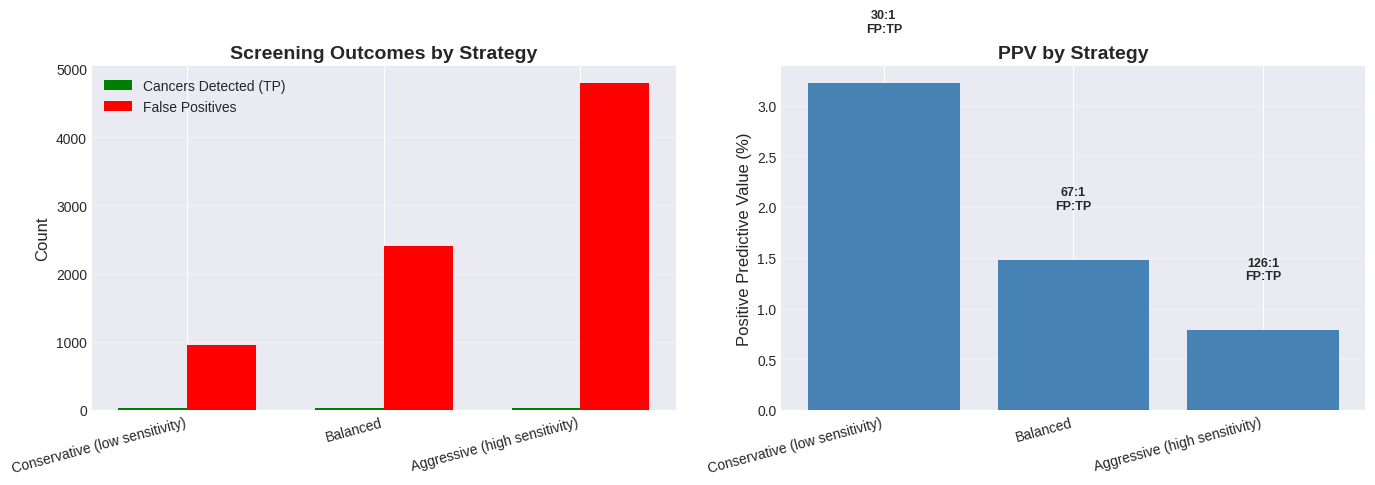

In [12]:
# Visualize trade-offs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of outcomes
ax = axes[0]
names = [r['name'] for r in results]
tps = [r['tp'] for r in results]
fps = [r['fp'] for r in results]

x = np.arange(len(names))
width = 0.35

ax.bar(x - width/2, tps, width, label='Cancers Detected (TP)', color='green')
ax.bar(x + width/2, fps, width, label='False Positives', color='red')

ax.set_ylabel('Count', fontsize=12)
ax.set_title('Screening Outcomes by Strategy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# PPV comparison
ax = axes[1]
ppvs = [r['ppv'] * 100 for r in results]
fp_ratios = [r['fp_ratio'] for r in results]

ax.bar(x, ppvs, color='steelblue')
ax.set_ylabel('Positive Predictive Value (%)', fontsize=12)
ax.set_title('PPV by Strategy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add FP ratio as text
for i, (ppv, ratio) in enumerate(zip(ppvs, fp_ratios)):
    ax.text(i, ppv + 0.5, f'{ratio:.0f}:1\nFP:TP',
           ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Key Takeaways

### What We Learned

1. **Object detection in medical imaging**:
   - Localization (bounding boxes) + classification
   - IoU metric for evaluating box accuracy
   - FROC curves for detection tasks (better than ROC)

2. **The false positive problem is inherent**:
   - Cancer prevalence: ~4% in screening populations
   - Benign nodules are common: ~30% of smokers have nodules
   - To achieve 90% sensitivity → accept ~60 FP per cancer
   - This is not a failure, it's the mathematical reality

3. **Clinical implications**:
   - Follow-up protocols needed for positive findings
   - Shared decision-making about screening
   - Balance: lives saved vs. anxiety/cost of false positives
   - AI systems should be calibrated for clinical workflows

4. **Why this matters for Jamal (Journey 3)**:
   - His 6mm nodule triggered surveillance
   - Serial CTs, eventual biopsy, 6 months of anxiety
   - The AI system was working correctly
   - But the experience highlights the human cost of FPs

5. **Technical lessons**:
   - FROC curves show sensitivity vs FP rate trade-off
   - IoU measures localization quality
   - Real systems use deep learning (Faster R-CNN, etc.)
   - Multi-stage: detection → classification → size tracking

### Connections to Book Chapters

- **Chapter 3 (Seven Journeys)**: Jamal's story provides the clinical motivation
- **Chapter 5 (Evaluation)**: FROC curves, IoU metric, detection vs classification
- **Chapter 6 (Imaging)**: This chapter - object detection, CNNs, medical imaging
- **Chapter 9 (Fairness)**: Nodule detection accuracy varies by ethnicity, smoking history
- **Chapter 11 (Deployment)**: Integration with radiologist workflow, false positive management

### Real-World Context

**National Lung Screening Trial (NLST)**:
- 20% mortality reduction with low-dose CT screening
- But: 96% of positive screens were false positives
- Benefits outweigh harms for high-risk individuals
- Requires careful patient selection and follow-up

**AI systems (e.g., Optellum, Lung.AI)**:
- Help prioritize which nodules need follow-up
- Analyze growth rates over serial scans
- Reduce unnecessary biopsies
- But can't eliminate false positives

### Next Steps in Practice

1. **Use real datasets**: LUNA16, LIDC-IDRI
2. **Deep learning detectors**: Faster R-CNN, RetinaNet, YOLO
3. **3D analysis**: Analyze full CT volumes, not just 2D slices
4. **Growth analysis**: Track nodules over time (more informative than single timepoint)
5. **Risk stratification**: Combine with clinical factors (age, smoking history, family history)

---

## Exercises

1. **Implement Non-Maximum Suppression (NMS)**: Remove overlapping duplicate detections

2. **Size-based risk stratification**: Larger nodules are more suspicious. Create separate FROC curves for nodules <6mm, 6-8mm, >8mm

3. **Growth analysis**: Generate serial CT scans 6 months apart. Implement growth detection. How much does this improve specificity?

4. **Cost-benefit analysis**: Assign costs (anxiety, radiation, biopsy complications) and benefits (life-years saved). What's the optimal operating point?

5. **Deep learning**: Implement a simple CNN-based detector using transfer learning from ImageNet

---

*This notebook is part of "AI in Healthcare" (Volume 1, Chapter 6: Medical Imaging)*  
*This implements Journey 3 (Jamal - Lung Nodule Detection) from Chapter 3*  
*For clinical context, see Chapter 3. For object detection methods, see Chapter 6.*